In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


In [3]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 224MB/s]



In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [6]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_983.jpg', 'with_mask_1159.jpg', 'with_mask_535.jpg', 'with_mask_887.jpg', 'with_mask_651.jpg']
['with_mask_3262.jpg', 'with_mask_424.jpg', 'with_mask_2192.jpg', 'with_mask_2764.jpg', 'with_mask_828.jpg']


In [7]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2555.jpg', 'without_mask_1853.jpg', 'without_mask_230.jpg', 'without_mask_22.jpg', 'without_mask_2923.jpg']
['without_mask_2026.jpg', 'without_mask_1693.jpg', 'without_mask_1005.jpg', 'without_mask_3585.jpg', 'without_mask_2795.jpg']


In [8]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


Creating Labels for the two class of Images

with mask --> 1

without mask --> 0

In [9]:
with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [10]:
labels = with_mask_labels + without_mask_labels

print(len(labels))

7553


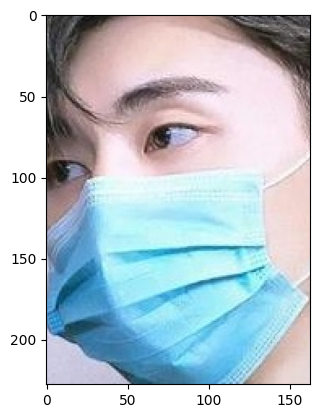

In [11]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

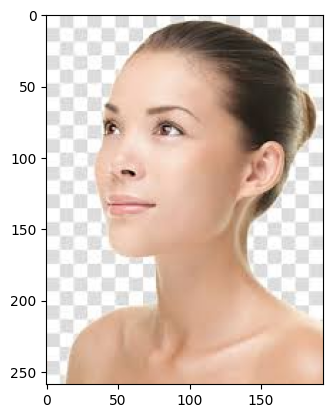

In [12]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

In [13]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


array([[[ 84,  71,  62],
        [ 84,  71,  62],
        [ 85,  72,  63],
        ...,
        [ 49,  51,  64],
        [ 50,  52,  65],
        [ 51,  53,  66]],

       [[ 80,  67,  58],
        [ 84,  71,  62],
        [ 90,  77,  68],
        ...,
        [ 47,  49,  62],
        [ 47,  49,  62],
        [ 47,  49,  62]],

       [[ 80,  67,  58],
        [ 85,  72,  63],
        [ 94,  81,  72],
        ...,
        [ 50,  52,  65],
        [ 48,  50,  63],
        [ 48,  50,  63]],

       ...,

       [[158, 149, 135],
        [154, 145, 132],
        [144, 137, 124],
        ...,
        [198, 168, 147],
        [199, 169, 146],
        [200, 169, 146]],

       [[156, 148, 138],
        [154, 147, 139],
        [152, 147, 139],
        ...,
        [196, 168, 146],
        [197, 169, 145],
        [198, 169, 145]],

       [[159, 151, 143],
        [164, 158, 150],
        [173, 170, 164],
        ...,
        [196, 168, 146],
        [197, 169, 145],
        [197, 169, 145]]], dtype=uint8)
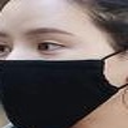

In [14]:
data[0]

In [15]:
type(data)

list

In [16]:
X = np.array(data)
Y = np.array(labels)

In [19]:
X_train, X_test, Y_train_s, Y_val_s = train_test_split(
    X, Y, test_size=0.1, random_state=42, stratify=Y
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}")

Train: (6797, 128, 128, 3)  Val: (756, 128, 128, 3)


In [20]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [21]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from keras.models import Sequential

In [22]:
from tensorflow.keras.regularizers import l2
num_of_classes = 2

model = Sequential([

    # ── Convolutional block 1
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    # ── Convolutional block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # ── Convolutional block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu',
          kernel_regularizer=l2(0.001)),        # L2 = 0.001
    Dropout(0.4),

    Dense(num_of_classes, activation='sigmoid'),
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
model.compile(
    optimizer=Adam(learning_rate=1e-4),         # lr = 0.0001
    loss='sparse_categorical_crossentropy',
    metrics=['acc'],
)


# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

checkpoint = ModelCheckpoint(
    'best_facemask_model.keras',
    monitor='val_acc',
    save_best_only=True,
    verbose=1,
)

callbacks = [early_stopping, reduce_lr, checkpoint]


#Training
history = model.fit(
    X_train_scaled, Y_train_s,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True,
)

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.7102 - loss: 0.7367
Epoch 1: val_acc improved from None to 0.87941, saving model to best_facemask_model.keras

Epoch 1: finished saving model to best_facemask_model.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - acc: 0.7991 - loss: 0.5737 - val_acc: 0.8794 - val_loss: 0.3840 - learning_rate: 1.0000e-04
Epoch 2/50
189/192 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - acc: 0.8907 - loss: 0.3563
Epoch 2: val_acc improved from 0.87941 to 0.88235, saving model to best_facemask_model.keras

Epoch 2: finished saving model to best_facemask_model.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - acc: 0.8967 - loss: 0.3399 - val_acc: 0.8824 - val_loss: 0.3251 - learning_rate: 1.0000e-04
Epoch 3/50
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9071 - loss: 0.2904
Epoch 3: val_acc improved from 0.88235 to 0.89853, saving model to best_facemask_model.keras

Epoch 3: finished saving model to best_facemask_model.keras
192/192 ━━━━━━━━━━━━━━

In [30]:
train_loss,train_acc = model.evaluate(X_train_scaled, Y_train_s, verbose=0)
print(f"\nTrain accuracy : {train_acc:.4f}")
print(f"Train loss     : {train_loss:.4f}")
test_loss, test_acc = model.evaluate(X_test_scaled, Y_val_s, verbose=0)
print(f"\nTest accuracy : {test_acc:.4f}")
print(f"Test loss     : {test_loss:.4f}")


Train accuracy : 0.9810
Train loss     : 0.1084

Test accuracy : 0.9497
Test loss     : 0.1900


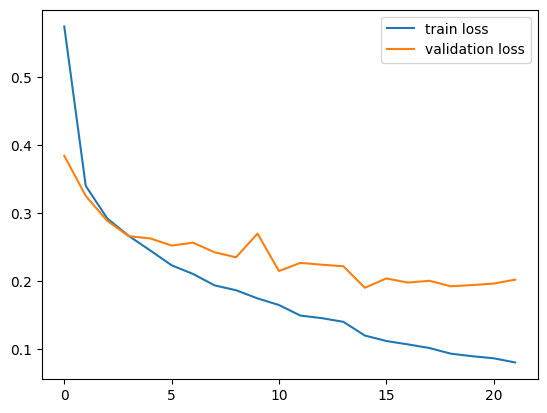

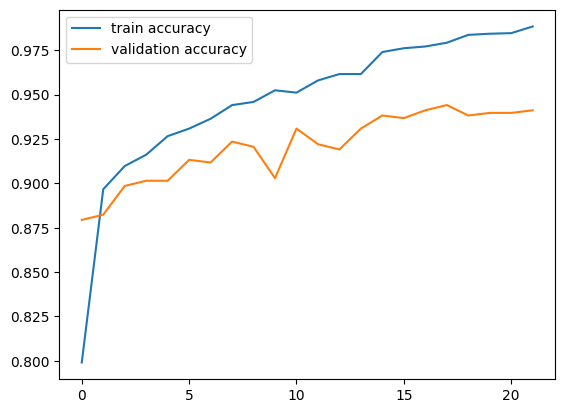

In [31]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

In [33]:
def Pred(input_image_path):

    input_image = cv2.imread(input_image_path)

    cv2_imshow(input_image)

    input_image_resized = cv2.resize(input_image, (128,128))

    input_image_scaled = input_image_resized/255

    input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

    input_prediction = model.predict(input_image_reshaped)

    print(input_prediction)


    input_pred_label = np.argmax(input_prediction)

    print(input_pred_label)


    if input_pred_label == 1:

      print('The person in the image is wearing a mask')

    else:

      print('The person in the image is not wearing a mask')

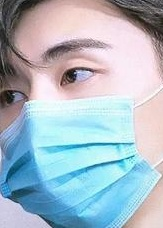

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 980ms/step
[[0.4660832  0.62663937]]
1
The person in the image is wearing a mask


In [34]:
Pred('/content/data/with_mask/with_mask_1545.jpg')